<a href="https://colab.research.google.com/github/ehfk45/Colab-/blob/main/%EB%B6%84%EB%A5%98_fish_KNN_%EC%8A%A4%EC%BC%80%EC%9D%BC%EB%A7%81%EC%A0%84%ED%9B%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

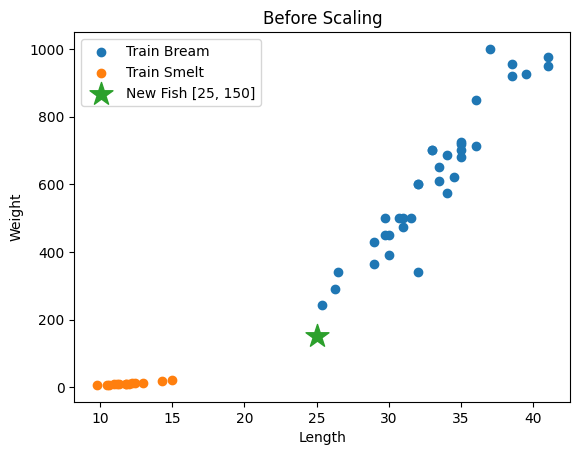

스케일링 전 예측: [0]
예측 결과: Smelt
테스트용 물고기 Z-score: [[-0.20271784 -0.90677444]]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


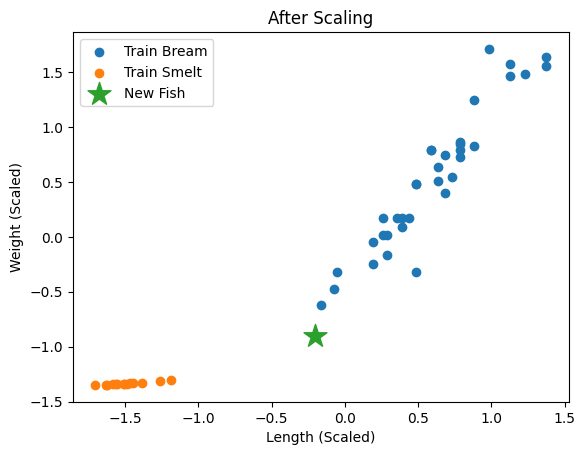

스케일링 후 예측: [1]
예측 결과: Bream


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# 1. 데이터 준비
# ============================================================

fish = pd.read_csv(
    "https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fish.csv"
)

# Bream과 Smelt만 선택
fish = fish[fish["Species"].isin(["Bream", "Smelt"])]


# ============================================================
# 2. 입력 데이터(X), 타깃 데이터(y)
# ============================================================

X_train = fish[["Length", "Weight"]]

# Bream = 1, Smelt = 0
y_train = fish["Species"].map({
    "Bream": 1,
    "Smelt": 0
})


# ============================================================
# 3. 새로운 물고기 지정
# ============================================================

# Length = 25
# Weight = 150
new_fish = [[25, 150]]


# ============================================================
# 4. 스케일링 전 산점도
# ============================================================

plt.figure()

# 훈련 데이터 - Bream
plt.scatter(
    X_train[y_train == 1]["Length"],
    X_train[y_train == 1]["Weight"],
    label="Train Bream"
)

# 훈련 데이터 - Smelt
plt.scatter(
    X_train[y_train == 0]["Length"],
    X_train[y_train == 0]["Weight"],
    label="Train Smelt"
)

# 새로운 물고기
plt.scatter(
    25,
    150,
    marker="*",
    s=300,
    label="New Fish [25, 150]"
)

plt.xlabel("Length")
plt.ylabel("Weight")
plt.title("Before Scaling")
plt.legend()
plt.show()


# ============================================================
# 5. 스케일링 전 KNN 학습
# ============================================================

kn = KNeighborsClassifier(n_neighbors=5)

# 원본 데이터로 학습
kn.fit(X_train, y_train)


# ============================================================
# 6. 스케일링 전 새로운 물고기 예측
# ============================================================

predict = kn.predict(new_fish)

print("스케일링 전 예측:", predict)

if predict[0] == 1:
    print("예측 결과: Bream")
else:
    print("예측 결과: Smelt")


# ============================================================
# 7. 표준화
# ============================================================

scaler = StandardScaler()

# 훈련 데이터의 평균과 표준편차를 구한 후 표준화
# fit_transform() 메서드는 fit() + transform() 역활
X_train_scaled = scaler.fit_transform(X_train)

# fit() or fit_transform() 메서드 전에 transform() 메서드 호출시 Error
# 새로운 물고기는 훈련 데이터의 기준(이미 fit_transform으로 학습된 평균/표준편차)으로 표준화
new_fish_scaled = scaler.transform(new_fish)
print('테스트용 물고기 Z-score:', new_fish_scaled)

# ============================================================
# 8. 스케일링 후 산점도
# ============================================================

plt.figure()

# 훈련 데이터 - Bream
plt.scatter(
    X_train_scaled[y_train == 1, 0],
    X_train_scaled[y_train == 1, 1],
    label="Train Bream"
)

# 훈련 데이터 - Smelt
plt.scatter(
    X_train_scaled[y_train == 0, 0],
    X_train_scaled[y_train == 0, 1],
    label="Train Smelt"
)

# 새로운 물고기
plt.scatter(
    new_fish_scaled[0, 0],
    new_fish_scaled[0, 1],
    marker="*",
    s=300,
    label="New Fish"
)

plt.xlabel("Length (Scaled)")
plt.ylabel("Weight (Scaled)")
plt.title("After Scaling")
plt.legend()
plt.show()


# ============================================================
# 9. 스케일링 후 KNN 학습
# ============================================================

kn_scaled = KNeighborsClassifier(n_neighbors=5)

# 표준화된 데이터로 학습
kn_scaled.fit(X_train_scaled, y_train)


# ============================================================
# 10. 스케일링 후 새로운 물고기 예측
# ============================================================

predict_scaled = kn_scaled.predict(new_fish_scaled)

print("스케일링 후 예측:", predict_scaled)

if predict_scaled[0] == 1:
    print("예측 결과: Bream")
else:
    print("예측 결과: Smelt")

In [ ]:
distances, indexes = kn.kneighbors(new_fish)

print("\n[스케일링 전]")
print("거리:", distances[0])
print("인덱스:", indexes[0])

print("\n가장 가까운 5개 데이터")

for distance, index in zip(distances[0], indexes[0]):
    length = X_train.iloc[index]["Length"]
    weight = X_train.iloc[index]["Weight"]
    species = fish.iloc[index]["Species"]

    print(
        f"거리={distance:.2f}, "
        f"좌표=({length}, {weight}), "
        f"종류={species}"
    )


[스케일링 전]
거리: [ 92.00086956 130.48375378 130.73859415 137.17988191 138.32150953]
인덱스: [ 0 48 47 45 46]

가장 가까운 5개 데이터
거리=92.00, 좌표=(25.4, 242.0), 종류=Bream
거리=130.48, 좌표=(15.0, 19.9), 종류=Smelt
거리=130.74, 좌표=(14.3, 19.7), 종류=Smelt
거리=137.18, 좌표=(12.4, 13.4), 종류=Smelt
거리=138.32, 좌표=(13.0, 12.2), 종류=Smelt


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
